In [1]:
import os
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}

===== MODEL PARAMETERS =====
Total Parameters:     2,226,434
Trainable Parameters: 2,226,434

Epoch [1/15]
Train Loss: 0.0599 | Train Acc: 0.9830
Val Loss:   0.0023 | Val Acc:   0.9990

Epoch [2/15]
Train Loss: 0.0067 | Train Acc: 0.9986
Val Loss:   0.0021 | Val Acc:   0.9990

Epoch [3/15]
Train Loss: 0.0047 | Train Acc: 0.9986
Val Loss:   0.0065 | Val Acc:   0.9970

Epoch [4/15]
Train Loss: 0.0041 | Train Acc: 0.9991
Val Loss:   0.0005 | Val Acc:   1.0000

Epoch [5/15]
Train Loss: 0.0033 | Train Acc: 0.9990
Val Loss:   0.0007 | Val Acc:   1.0000

Epoch [6/15]
Train Loss: 0.0015 | Train Acc: 0.9995
Val Loss:   0.0005 | Val Acc:   1.0000

Epoch [7/15]
Train Loss: 0.0009 | Train Acc: 0.9996
Val Loss:   0.0005 | Val Acc:   1.0000

Epoch [8/15]
Train Loss: 0.0005 | Train Acc: 0.9999
Val Loss:   0.0002 | Val Acc:   1.0000

Epoch [9/15]
Train Loss: 0.0003 | Train Acc: 1.0000
Val Loss:   0.0004 | Val Acc:   1.0000

Epoch [10/15]
Train 

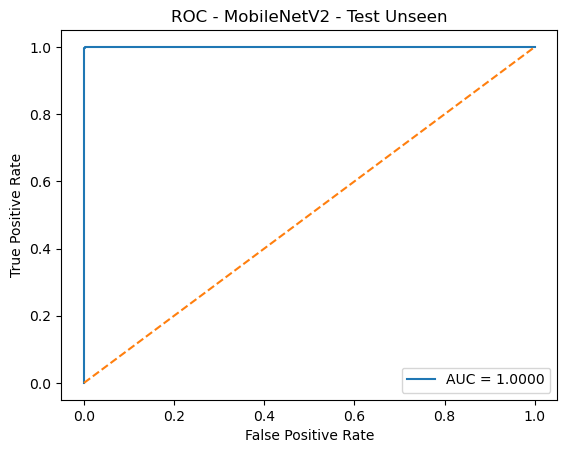

In [2]:
# ===============================
# 1️⃣ REPRODUCIBILITY
# ===============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ===============================
# 2️⃣ CONFIG
# ===============================
DATA_ROOT = r"D:\Datasets\Phase1_224x224_RGB"
MODEL_SAVE_PATH = r"D:\MinorProject\MinorProject6thSem\models\best_mobilenetv2_rgb_phase1.pth"

BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ===============================
# 3️⃣ TRANSFORMS
# ===============================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ===============================
# 4️⃣ DATASETS
# ===============================
train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), transform=test_transform)
test_seen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_seen"), transform=test_transform)
test_unseen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_unseen"), transform=test_transform)

print("Class mapping:", train_dataset.class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ===============================
# 5️⃣ MODEL (MobileNetV2)
# ===============================
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

model = model.to(DEVICE)

# ===============================
# 🔢 PARAMETER COUNT
# ===============================
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)

print("\n===== MODEL PARAMETERS =====")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# ===============================
# 6️⃣ LOSS, OPTIMIZER, SCHEDULER
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ===============================
# 7️⃣ EVALUATION FUNCTION
# ===============================
def evaluate(model, loader, return_preds=False, return_probs=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = F.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if return_probs:
                all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    if return_preds and return_probs:
        return avg_loss, accuracy, all_preds, all_labels, all_probs
    if return_preds:
        return avg_loss, accuracy, all_preds, all_labels
    return avg_loss, accuracy

# ===============================
# 8️⃣ TRAINING LOOP
# ===============================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_acc = running_corrects / total
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

# ===============================
# 🔟 SAVE BEST MODEL
# ===============================
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("\nBest model saved locally (overwritten).")

# ===============================
# 9️⃣ FINAL EVALUATION
# ===============================
train_loss, train_acc = evaluate(model, train_loader)
val_loss, val_acc = evaluate(model, val_loader)

test_seen_loss, test_seen_acc, seen_preds, seen_labels = evaluate(model, test_seen_loader, True)
test_unseen_loss, test_unseen_acc, unseen_preds, unseen_labels, unseen_probs = evaluate(
    model, test_unseen_loader, return_preds=True, return_probs=True
)

fpr, tpr, _ = roc_curve(unseen_labels, unseen_probs)
roc_auc = auc(fpr, tpr)

print("\n===== FINAL RESULTS =====")
print(f"Train Loss:       {train_loss:.4f} | Train Acc:       {train_acc:.4f}")
print(f"Validation Loss:  {val_loss:.4f} | Validation Acc:  {val_acc:.4f}")
print(f"Test Seen Loss:   {test_seen_loss:.4f} | Test Seen Acc:   {test_seen_acc:.4f}")
print(f"Test Unseen Loss: {test_unseen_loss:.4f} | Test Unseen Acc: {test_unseen_acc:.4f}")
print(f"Test Unseen AUC:  {roc_auc:.4f}")

print("\nConfusion Matrix - Test Unseen")
print(confusion_matrix(unseen_labels, unseen_preds))
print(classification_report(unseen_labels, unseen_preds))

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - MobileNetV2 - Test Unseen")
plt.legend()
plt.show()